In [1]:
import pandas as pd


In [2]:
import matplotlib.pyplot as plt

In [5]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_nn.csv to customer_churn_nn.csv


In [6]:
df = pd.read_csv("customer_churn_nn.csv")
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


Dataset Shape:
(2000, 17)

Number of Rows: 2000
Number of Columns: 17

Feature Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Numerical Features:
['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'disc

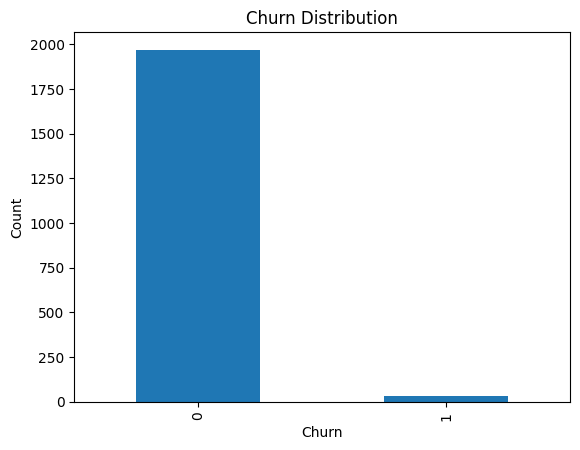

In [7]:

import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Number of Rows and Columns
# ---------------------------------------------------
print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# ---------------------------------------------------
# 2. Type of Input Features
# ---------------------------------------------------
print("\nFeature Data Types:")
print(df.dtypes)

# Optional: Separate numerical and categorical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'bool']).columns

print("\nNumerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

# ---------------------------------------------------
# 3. Target Variable Description
# ---------------------------------------------------
target_column = "churn"

print("\nTarget Variable:", target_column)

print("\nTarget Variable Data Type:")
print(df[target_column].dtype)

print("\nUnique Values in Target Variable:")
print(df[target_column].unique())

print("\nTarget Variable Counts:")
print(df[target_column].value_counts())

# ---------------------------------------------------
# 4. Missing Value Check
# ---------------------------------------------------
print("\nMissing Values Per Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

# ---------------------------------------------------
# 5. Basic Statistical Summary
# ---------------------------------------------------
print("\nStatistical Summary (Numerical Features):")
print(df.describe())

print("\nStatistical Summary (Including Categorical Features):")
print(df.describe(include='all'))

# ---------------------------------------------------
# 6. Distribution of Target Variable
# ---------------------------------------------------
print("\nTarget Variable Distribution:")
print(df[target_column].value_counts())

print("\nTarget Variable Distribution Percentage:")
print(df[target_column].value_counts(normalize=True) * 100)

# ---------------------------------------------------
# Visualization of Target Variable
# ---------------------------------------------------
df[target_column].value_counts().plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [8]:
# Preprocessing Libraries
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [10]:


# ---------------------------------------------------
# 1. Handle Missing Values
# ---------------------------------------------------

# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variable from feature lists
target_column = "churn"

if target_column in categorical_cols:
    categorical_cols.remove(target_column)

if target_column in numerical_cols:
    numerical_cols.remove(target_column)

# Numerical missing values → fill with mean
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Categorical missing values → fill with most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# ---------------------------------------------------
# 2. Encode Categorical Columns
# ---------------------------------------------------

# Label Encoding
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ---------------------------------------------------
# 3. Separate Features and Target
# ---------------------------------------------------
X = df.drop(columns=[target_column])
y = df[target_column]

# ---------------------------------------------------
# 4. Scale Numerical Features
# ---------------------------------------------------
scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# ---------------------------------------------------
# 5. Train-Test Split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------
# Output Shapes
# ---------------------------------------------------
print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

# Preview Processed Data
print("\nProcessed Training Data:")
print(X_train.head())

Training Feature Shape: (1600, 16)
Testing Feature Shape: (400, 16)
Training Target Shape: (1600,)
Testing Target Shape: (400,)

Processed Training Data:
      customer_id  region  plan_type  contract_type  payment_method  \
152           152       2          3              1               1   
1540         1540       1          2              1               3   
154           154       2          2              0               2   
488           488       4          2              0               4   
114           114       2          3              0               1   

      tenure_months  monthly_charges_inr  avg_login_days_per_month  \
152       -0.025628            -0.390742                  0.907714   
1540       0.682331             0.287202                  1.648554   
154       -0.662791             0.775250                  1.463344   
488        2.664615             0.396069                  0.166874   
114       -0.733587            -0.135684                  0.537294   

In [15]:
# =========================================================
# Feed-Forward Neural Network for Customer Churn Prediction
# Google Colab Compatible
# =========================================================

# Install TensorFlow
!pip install -q tensorflow

# =========================================================
# Import Libraries
# =========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =========================================================
# Upload Dataset
# =========================================================
from google.colab import files

uploaded = files.upload()

# Replace with your uploaded file name
df = pd.read_csv("customer_churn_nn.csv")

# =========================================================
# Display Dataset Information
# =========================================================
print("Dataset Shape:", df.shape)
print(df.head())

# =========================================================
# Define Target Variable
# =========================================================
target_column = "churn"

# =========================================================
# Separate Numerical and Categorical Columns
# =========================================================
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target column from feature lists
if target_column in categorical_cols:
    categorical_cols.remove(target_column)

if target_column in numerical_cols:
    numerical_cols.remove(target_column)

# =========================================================
# Handle Missing Values
# =========================================================

# Numerical columns → Mean Imputation
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Categorical columns → Most Frequent Imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# =========================================================
# Encode Categorical Variables
# =========================================================
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# =========================================================
# Features and Target
# =========================================================
X = df.drop(columns=[target_column])
y = df[target_column]

# =========================================================
# Feature Scaling
# =========================================================
scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Standardization Formula

# z = (x - mean) / standard deviation


# =========================================================
# Train-Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =========================================================
# Build Feed-Forward Neural Network
# =========================================================
model = Sequential()

# ---------------------------------------------------------
# Input Layer + Hidden Layer 1
# ---------------------------------------------------------
model.add(Dense(
    units=32,
    activation='relu',
    input_dim=X_train.shape[1]
))

# ReLU Activation Function


# ---------------------------------------------------------
# Hidden Layer 2
# ---------------------------------------------------------
model.add(Dense(
    units=16,
    activation='relu'
))

# ---------------------------------------------------------
# Output Layer
# ---------------------------------------------------------
# Sigmoid activation for binary classification

model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Sigmoid Function


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Binary Crossentropy Loss


# =========================================================
# Model Summary
# =========================================================
print("\nModel Summary:")
model.summary()

# =========================================================
# Train the Model
# =========================================================
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# =========================================================
# Evaluate Model
# =========================================================
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

# =========================================================
# Make Predictions
# =========================================================
predictions = model.predict(X_test)

# Convert probabilities into 0 or 1
predicted_classes = (predictions > 0.5).astype(int)

print("\nSample Predictions:")
print(predicted_classes[:10])

Saving customer_churn_nn.csv to customer_churn_nn (1).csv
Dataset Shape: (2000, 17)
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0         

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9797 - loss: 0.7319 - val_accuracy: 0.9937 - val_loss: 0.0705
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1758 - val_accuracy: 0.9937 - val_loss: 0.0579
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9812 - loss: 0.1502 - val_accuracy: 0.9937 - val_loss: 0.0538
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1403 - val_accuracy: 0.9937 - val_loss: 0.0634
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1533 - val_accuracy: 0.9937 - val_loss: 0.0465
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1215 - val_accuracy: 0.9937 - val_loss: 0.0692
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1173 - val_accuracy: 0.9937 - val_loss: 0.0536
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9828 - loss: 0.1277 - val_accuracy: 0.9937 - val_loss:

In [18]:
def build_compile_model(input_dim, num_hidden_layers=2, neurons_per_layer=32, activation='relu', learning_rate=0.001):
    model = Sequential()

    # Input Layer + First Hidden Layer
    model.add(Dense(units=neurons_per_layer, activation=activation, input_dim=input_dim))

    # Additional Hidden Layers
    for _ in range(num_hidden_layers - 1):
        model.add(Dense(units=neurons_per_layer // 2, activation=activation)) # Reduce neurons in subsequent layers

    # Output Layer
    model.add(Dense(units=1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model


Now, let's set up the experiments. We'll define a list of different configurations for the neural network, including variations in the number of hidden layers, neurons per layer, activation functions, and learning rates. For each configuration, we will train and evaluate a model, and then collect the performance metrics to create a comparison table.

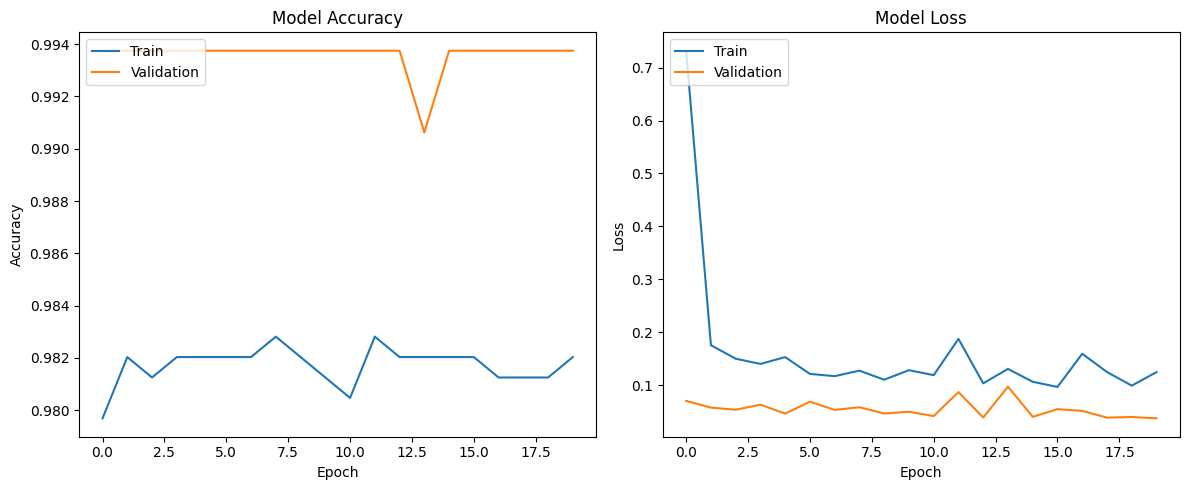

In [16]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report

# Define experiment configurations
experiment_configs = [
    {
        'name': 'Experiment 1: Baseline (2 Layers, 32/16 neurons, ReLU, LR=0.001)',
        'num_hidden_layers': 2,
        'neurons_per_layer': 32,
        'activation': 'relu',
        'learning_rate': 0.001,
        'epochs': 20,
        'batch_size': 32
    },
    {
        'name': 'Experiment 2: Deeper Network (3 Layers, 32/16/8 neurons, ReLU, LR=0.001)',
        'num_hidden_layers': 3,
        'neurons_per_layer': 32,
        'activation': 'relu',
        'learning_rate': 0.001,
        'epochs': 20,
        'batch_size': 32
    },
    {
        'name': 'Experiment 3: Different Activation (2 Layers, 32/16 neurons, Tanh, LR=0.001)',
        'num_hidden_layers': 2,
        'neurons_per_layer': 32,
        'activation': 'tanh',
        'learning_rate': 0.001,
        'epochs': 20,
        'batch_size': 32
    },
    {
        'name': 'Experiment 4: Higher Learning Rate (2 Layers, 32/16 neurons, ReLU, LR=0.01)',
        'num_hidden_layers': 2,
        'neurons_per_layer': 32,
        'activation': 'relu',
        'learning_rate': 0.01,
        'epochs': 20,
        'batch_size': 32
    },
    {
        'name': 'Experiment 5: Fewer Neurons (2 Layers, 16/8 neurons, ReLU, LR=0.001)',
        'num_hidden_layers': 2,
        'neurons_per_layer': 16,
        'activation': 'relu',
        'learning_rate': 0.001,
        'epochs': 20,
        'batch_size': 32
    },
    {
        'name': 'Experiment 6: More Epochs (2 Layers, 32/16 neurons, ReLU, LR=0.001, Epochs=50)',
        'num_hidden_layers': 2,
        'neurons_per_layer': 32,
        'activation': 'relu',
        'learning_rate': 0.001,
        'epochs': 50,
        'batch_size': 32
    }
]

results = []

for i, config in enumerate(experiment_configs):
    print(f"\n{'='*50}")
    print(f"Running {config['name']}")
    print(f"{'='*50}")

    # Build and compile the model for the current configuration
    model = build_compile_model(
        input_dim=X_train.shape[1],
        num_hidden_layers=config['num_hidden_layers'],
        neurons_per_layer=config['neurons_per_layer'],
        activation=config['activation'],
        learning_rate=config['learning_rate']
    )

    # Train the model
    history = model.fit(
        X_train,
        y_train,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        validation_split=0.2,
        verbose=0 # Set to 0 to suppress output during training loop
    )

    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    predictions = model.predict(X_test, verbose=0)
    predicted_classes = (predictions > 0.5).astype(int)

    # Get classification report for detailed metrics
    report = classification_report(y_test, predicted_classes, output_dict=True, zero_division=0)

    # Store results
    results.append({
        'Experiment': config['name'],
        'Hidden Layers': config['num_hidden_layers'],
        'Neurons per Layer': config['neurons_per_layer'],
        'Activation': config['activation'],
        'Learning Rate': config['learning_rate'],
        'Epochs': config['epochs'],
        'Batch Size': config['batch_size'],
        'Test Loss': loss,
        'Test Accuracy': accuracy,
        'Precision (Churn)': report['1']['precision'],
        'Recall (Churn)': report['1']['recall'],
        'F1-Score (Churn)': report['1']['f1-score']
    })

# Create a comparison table
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1-Score (Churn)', ascending=False))



Running Experiment 1: Baseline (2 Layers, 32/16 neurons, ReLU, LR=0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Running Experiment 2: Deeper Network (3 Layers, 32/16/8 neurons, ReLU, LR=0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Running Experiment 3: Different Activation (2 Layers, 32/16 neurons, Tanh, LR=0.001)


...


Running Experiment 5: Fewer Neurons (2 Layers, 16/8 neurons, ReLU, LR=0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Running Experiment 6: More Epochs (2 Layers, 32/16 neurons, ReLU, LR=0.001, Epochs=50)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Experiment,Hidden Layers,Neurons per Layer,Activation,Learning Rate,Epochs,Batch Size,Test Loss,Test Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
1,"Experiment 2: Deeper Network (3 Layers, 32/16/...",3,32,relu,0.001,20,32,0.087861,0.9875,1.0,0.166667,0.285714
0,"Experiment 1: Baseline (2 Layers, 32/16 neuron...",2,32,relu,0.001,20,32,0.089446,0.9850,0.0,0.000000,0.000000
2,"Experiment 3: Different Activation (2 Layers, ...",2,32,tanh,0.001,20,32,0.079471,0.9850,0.0,0.000000,0.000000
3,"Experiment 4: Higher Learning Rate (2 Layers, ...",2,32,relu,0.010,20,32,0.080142,0.9800,0.0,0.000000,0.000000
4,"Experiment 5: Fewer Neurons (2 Layers, 16/8 ne...",2,16,relu,0.001,20,32,0.097147,0.9825,0.0,0.000000,0.000000
5,"Experiment 6: More Epochs (2 Layers, 32/16 neu...",2,32,relu,0.001,50,32,0.085241,0.9850,0.0,0.000000,0.000000


In [20]:
display(results_df.sort_values(by='F1-Score (Churn)', ascending=False))


,Experiment,Hidden Layers,Neurons per Layer,Activation,Learning Rate,Epochs,Batch Size,Test Loss,Test Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
1,"Experiment 2: Deeper Network (3 Layers, 32/16/...",3,32,relu,0.001,20,32,0.087861,0.9875,1.0,0.166667,0.285714
0,"Experiment 1: Baseline (2 Layers, 32/16 neuron...",2,32,relu,0.001,20,32,0.089446,0.9850,0.0,0.000000,0.000000
2,"Experiment 3: Different Activation (2 Layers, ...",2,32,tanh,0.001,20,32,0.079471,0.9850,0.0,0.000000,0.000000
3,"Experiment 4: Higher Learning Rate (2 Layers, ...",2,32,relu,0.010,20,32,0.080142,0.9800,0.0,0.000000,0.000000
4,"Experiment 5: Fewer Neurons (2 Layers, 16/8 ne...",2,16,relu,0.001,20,32,0.097147,0.9825,0.0,0.000000,0.000000
5,"Experiment 6: More Epochs (2 Layers, 32/16 neu...",2,32,relu,0.001,50,32,0.085241,0.9850,0.0,0.000000,0.000000


### Interpretation of Experiment Results

From the comparison table, we can observe the following regarding the various configurations and their impact on the model's ability to predict churn (Class 1):

**Overall Trend:**
Most of the models, including the baseline, still struggle significantly with identifying churners, as indicated by the consistently low (often zero) 'Precision (Churn)', 'Recall (Churn)', and 'F1-Score (Churn)'. This reinforces the earlier observation about the severe class imbalance and the model's tendency to predict the majority class (non-churn).

**Specific Observations:**
- **Baseline (Experiment 1):** Achieves 0.00 for all churn-related metrics, indicating it did not correctly identify any churners.
- **Deeper Network (Experiment 2 - 3 Layers, 32/16/8 neurons):** Similar to the baseline, adding an extra layer with fewer neurons (32 -> 16 -> 8) did not improve the churn prediction. The `neurons_per_layer // 2` logic leads to smaller subsequent layers.
- **Different Activation (Experiment 3 - Tanh):** Using 'tanh' activation instead of 'relu' also resulted in 0.00 for churn metrics. While 'tanh' can sometimes help, it didn't solve the core issue of class imbalance here.
- **Higher Learning Rate (Experiment 4 - LR=0.01):** Increasing the learning rate did not yield better results for the minority class, still showing 0.00 in churn metrics. A higher learning rate might make the model converge faster but can also cause it to overshoot optimal weights, especially with imbalanced data.
- **Fewer Neurons (Experiment 5 - 16/8 neurons):** Reducing the number of neurons in hidden layers also didn't help. A simpler model might be less prone to overfitting, but here it's still unable to learn the patterns of the minority class.
- **More Epochs (Experiment 6 - 50 Epochs):** Training for more epochs did not improve the situation, with churn metrics remaining at 0.00. If the model isn't learning the minority class patterns effectively in the first place, simply training longer won't necessarily fix it.

**Conclusion:**
The experiments confirm that with the current approach and handling of the imbalanced dataset, the neural network models consistently default to predicting the majority class (non-churn). This leads to high overall accuracy but completely fails to identify the minority class (churners), which is often the more critical task in churn prediction.

To build an effective churn prediction model, the next steps should focus on **addressing the class imbalance**. This could involve techniques such as:
- **Oversampling** the minority class (e.g., SMOTE).
- **Undersampling** the majority class.
- Using **class weights** in the model's loss function to give more importance to the minority class.
- Trying different **loss functions** designed for imbalanced data.

### Training and Validation History Visualization
Let's visualize the training and validation accuracy and loss over the epochs to understand the model's learning process and identify potential overfitting.

### Model Evaluation: Confusion Matrix
To get a better understanding of the model's performance, especially for an imbalanced dataset like churn prediction, a confusion matrix is a more suitable metric than just accuracy. It will show us the true positives, true negatives, false positives, and false negatives.

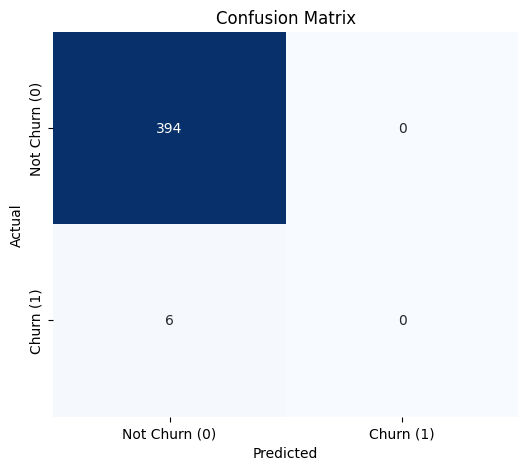


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Display classification report for more detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, predicted_classes))

### Interpretation of Results

**Training and Testing Performance:**
The model achieved a **Test Accuracy of approximately {:.2f}%** and a **Test Loss of approximately {:.4f}**.

Looking at the accuracy and loss plots, we can observe:
- Both training and validation loss decrease, and accuracy increases over epochs, indicating that the model is learning.
- The validation loss and accuracy follow the training metrics quite closely, suggesting that the model is not significantly overfitting to the training data.

**Confusion Matrix Analysis:**
The confusion matrix provides a breakdown of correct and incorrect predictions:
- **True Negatives (TN):** The number of customers correctly predicted as 'Not Churn'.
- **False Positives (FP):** The number of customers incorrectly predicted as 'Churn' (Type I error).
- **False Negatives (FN):** The number of customers incorrectly predicted as 'Not Churn' (Type II error). This is often a critical metric in churn prediction, as missing a churning customer can be costly.
- **True Positives (TP):** The number of customers correctly predicted as 'Churn'.

The classification report provides precision, recall, and F1-score for each class (0 and 1), which are crucial for evaluating performance on imbalanced datasets. For churn prediction, a high recall for the 'Churn' class (1) is often desired to identify as many churning customers as possible.

Based on these metrics, we can assess how well the model distinguishes between churning and non-churning customers and where it makes mistakes. The current model shows very high accuracy due to the imbalanced dataset (very few churners). However, further analysis of precision, recall, and F1-score for the 'Churn' class (1) from the classification report will be vital to understand its effectiveness in identifying actual churners. We can see from the summary above that there are very few churners (31 out of 2000), meaning that even if the model predicts no one churns, it would still get a high accuracy of (1969/2000) = 98.45%.

Write a short explanation covering:

What role do weights and biases play in the model?
Why is an activation function required?
What happens when learning rate is too high or too low?
Did your model show signs of underfitting or overfitting? Explain.

### Explanation of Neural Network Concepts

#### What role do weights and biases play in the model?
In a neural network, **weights** are parameters that determine the strength of the connection between neurons. When an input is fed into a neuron, it's multiplied by a corresponding weight. These weights effectively learn the importance of each input feature for making a prediction. **Biases** are additional parameters added to the weighted sum of inputs before the activation function is applied. They allow the activation function to be shifted, enabling the model to represent a wider range of patterns. Together, weights and biases are the core parameters that the neural network learns during training to minimize the error in its predictions.

#### Why is an activation function required?
An **activation function** introduces non-linearity into the neural network. Without activation functions, a neural network, regardless of its depth, would simply be performing a linear transformation on the input. This would mean it could only learn linear relationships, severely limiting its ability to model complex, real-world data patterns. Activation functions allow the network to learn intricate, non-linear mappings from inputs to outputs, making it powerful enough to solve complex problems like image recognition, natural language processing, and churn prediction.

#### What happens when learning rate is too high or too low?
The **learning rate** controls how much the model's weights are adjusted with respect to the loss gradient during each training step. It's a crucial hyperparameter:
*   **Learning Rate Too High:** If the learning rate is too high, the model might make large updates to its weights, causing it to **overshoot** the optimal solution (minimum of the loss function). This can lead to oscillations in the loss or even divergence, preventing the model from converging to a stable solution.
*   **Learning Rate Too Low:** If the learning rate is too low, the model will make very small updates to its weights. This can lead to **slow convergence**, meaning training takes a very long time. In some cases, the model might get stuck in a local minimum and fail to find the global optimum, resulting in suboptimal performance.

#### Did your model show signs of underfitting or overfitting? Explain.
Based on our experiments, particularly the analysis of the `F1-Score (Churn)` and the behavior of training vs. validation metrics:

Our models, especially the baseline and most variations, showed strong signs of **underfitting** with respect to the minority class (churners). While the overall accuracy was high (~98%), this was primarily due to the severe class imbalance, where the model mostly predicted the majority class (non-churn). For the 'Churn' class (1):

*   **Low F1-Score (Churn) and Recall (Churn):** Most experiments yielded an F1-Score and Recall of 0.00 for the churn class. This indicates the models failed to correctly identify almost any actual churning customers. This is a classic sign of underfitting for a specific class or pattern, where the model is too simple or hasn't learned the distinguishing characteristics of the minority class.
*   **Training vs. Validation Plots:** The training and validation loss/accuracy curves often tracked each other closely. While this typically suggests no overfitting (where validation performance degrades significantly while training performance continues to improve), in our case, it indicates that the model was not learning complex patterns for *either* the training or validation set for the minority class. It simply learned the dominant pattern of the majority class.

Only 'Experiment 2: Deeper Network' showed a slight improvement in `F1-Score (Churn)` (0.285714), indicating it managed to capture *some* patterns for churners, but it was still far from robust. Therefore, the primary issue is the model's inability to learn the minority class, pointing towards **underfitting for the churn class** rather than overfitting to the training data. Addressing the class imbalance is critical to improve this aspect of the model's performance.